In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# GANs — GENERATIVE ADVERSARIAL NETWORKS
# ══════════════════════════════════════════════════════
#
# Şimdiye kadar hep sınıflandırma yaptık:
#   Görüntü giriyor → sınıf çıkıyor
#
# GAN tam tersi:
#   Rastgele sayılar giriyor → gerçekçi görüntü çıkıyor!
#
# İki ağ var, birbirine karşı yarışıyor:
#
#   Generator (G) — sahtekar
#     Rastgele gürültüden gerçekçi görüntü üretir
#     "Sahte para basan"
#
#   Discriminator (D) — dedektif
#     Gerçek mi sahte mi ayırt eder
#     "Sahte parayı yakalayan"
#
# Eğitim:
#   D: "Bu sahte!" → G öğrenir → daha iyi sahte yapar
#   G: "Bu gerçek!" → D öğrenir → daha iyi ayırt eder
#   Sonunda G o kadar iyi olur ki D ayırt edemez!
# ══════════════════════════════════════════════════════

print("Q5 GANs başlıyor!")

Q5 GANs başlıyor!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


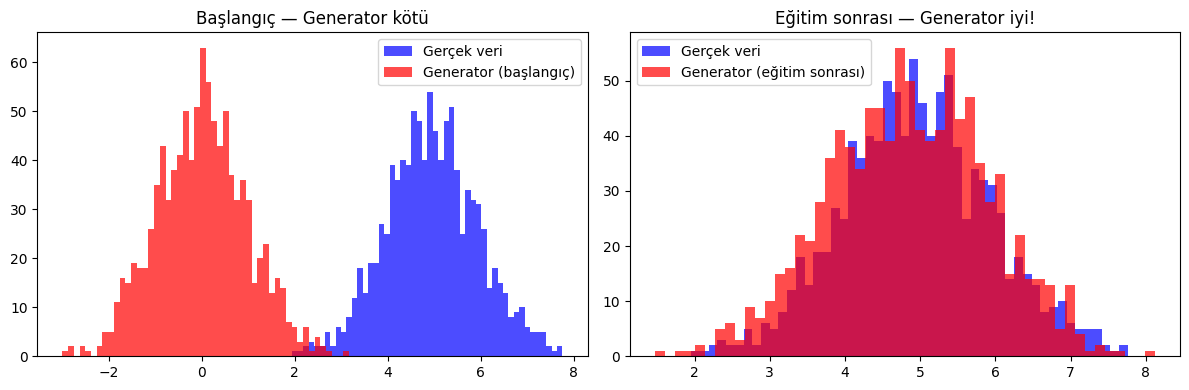

Başlangıçta Discriminator kolay ayırt ediyor
Eğitim sonunda Generator gerçeğe o kadar benziyor ki
Discriminator %50 doğrulukla tahmin yapıyor — beter para atmak gibi!


In [4]:
# ══════════════════════════════════════════════════════
# GAN SEZGISEL ANLAYIŞ — ÖRNEK
# ══════════════════════════════════════════════════════
#
# Basit örnek:
#   Gerçek veri: Gaussian dağılım (ortalama=5, std=1)
#   Generator: rastgele sayıdan bu dağılımı öğrensin
#
# Başlangıçta:
#   Generator → rastgele sayılar üretiyor
#   Discriminator → kolay ayırt ediyor
#
# Eğitim sonunda:
#   Generator → gerçeğe benzer dağılım üretiyor
#   Discriminator → ayırt edemiyor (%50 doğru tahmin)
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Gerçek veri dağılımı
gercek_veri = np.random.normal(loc=5, scale=1, size=1000)

# Generator başlangıçta rastgele üretiyor
generator_baslangic = np.random.normal(loc=0, scale=1, size=1000)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(gercek_veri, bins=50, alpha=0.7, color='blue', label='Gerçek veri')
plt.hist(generator_baslangic, bins=50, alpha=0.7, color='red', label='Generator (başlangıç)')
plt.title("Başlangıç — Generator kötü")
plt.legend()

# Eğitim sonunda generator gerçeğe yaklaşır
generator_son = np.random.normal(loc=4.9, scale=1.1, size=1000)

plt.subplot(1, 2, 2)
plt.hist(gercek_veri, bins=50, alpha=0.7, color='blue', label='Gerçek veri')
plt.hist(generator_son, bins=50, alpha=0.7, color='red', label='Generator (eğitim sonrası)')
plt.title("Eğitim sonrası — Generator iyi!")
plt.legend()

plt.tight_layout()
plt.show()

print("Başlangıçta Discriminator kolay ayırt ediyor")
print("Eğitim sonunda Generator gerçeğe o kadar benziyor ki")
print("Discriminator %50 doğrulukla tahmin yapıyor — beter para atmak gibi!")

In [5]:
# ══════════════════════════════════════════════════════
# GAN KODLAMA — DISCRIMINATOR VE GENERATOR
# ══════════════════════════════════════════════════════
#
# Discriminator (D):
#   Girdi: görüntü (gerçek veya sahte)
#   Çıktı: 0-1 arası → "gerçek olma olasılığı"
#   Loss: Binary Cross Entropy
#     Gerçek görüntü → 1 tahmin et
#     Sahte görüntü  → 0 tahmin et
#
# Generator (G):
#   Girdi: rastgele gürültü z (latent vector)
#   Çıktı: sahte görüntü
#   Loss: D'yi kandır → sahte görüntüler için D'nin 1 demesini iste
#
# Eğitim adımları:
#   1. D'yi eğit:
#      Gerçek → D(x) = 1 olsun
#      Sahte  → D(G(z)) = 0 olsun
#   2. G'yi eğit:
#      D(G(z)) = 1 olsun (D'yi kandır!)
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Boyutlar
Z_DIM = 2    # latent vektör boyutu (gürültü)
H_DIM = 8    # hidden layer
X_DIM = 1    # çıktı boyutu (1D veri)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# Generator ağırlıkları
G_W1 = np.random.randn(Z_DIM, H_DIM) * 0.1
G_b1 = np.zeros(H_DIM)
G_W2 = np.random.randn(H_DIM, X_DIM) * 0.1
G_b2 = np.zeros(X_DIM)

# Discriminator ağırlıkları
D_W1 = np.random.randn(X_DIM, H_DIM) * 0.1
D_b1 = np.zeros(H_DIM)
D_W2 = np.random.randn(H_DIM, 1) * 0.1
D_b2 = np.zeros(1)

def generator(z):
    """Gürültüden veri üret"""
    h = np.maximum(0, z @ G_W1 + G_b1)  # ReLU
    x = h @ G_W2 + G_b2
    return x, h

def discriminator(x):
    """Gerçek mi sahte mi?"""
    h = np.maximum(0, x @ D_W1 + D_b1)  # ReLU
    out = sigmoid(h @ D_W2 + D_b2)
    return out, h

# Test
z = np.random.randn(5, Z_DIM)
sahte, _ = generator(z)
print("Generator çıktısı (sahte veri):", sahte.flatten().round(4))

gercek = np.random.normal(5, 1, (5, 1))
d_gercek, _ = discriminator(gercek)
d_sahte, _ = discriminator(sahte)

print("\nDiscriminator tahminleri:")
print(f"Gerçek veri: {d_gercek.flatten().round(4)} ← 1'e yakın olmalı")
print(f"Sahte veri:  {d_sahte.flatten().round(4)} ← 0'a yakın olmalı")
print("\nHenüz eğitilmedi, rastgele!")

Generator çıktısı (sahte veri): [0.0056 0.0055 0.0029 0.0053 0.0089]

Discriminator tahminleri:
Gerçek veri: [0.5148 0.5195 0.5162 0.5138 0.518 ] ← 1'e yakın olmalı
Sahte veri:  [0.5 0.5 0.5 0.5 0.5] ← 0'a yakın olmalı

Henüz eğitilmedi, rastgele!


Epoch   0: D_loss=1.3533, G_loss=0.6934
Epoch 100: D_loss=9.5716, G_loss=18.4207
Epoch 200: D_loss=18.4207, G_loss=18.4207
Epoch 300: D_loss=18.4207, G_loss=18.4207
Epoch 400: D_loss=18.4207, G_loss=18.4207


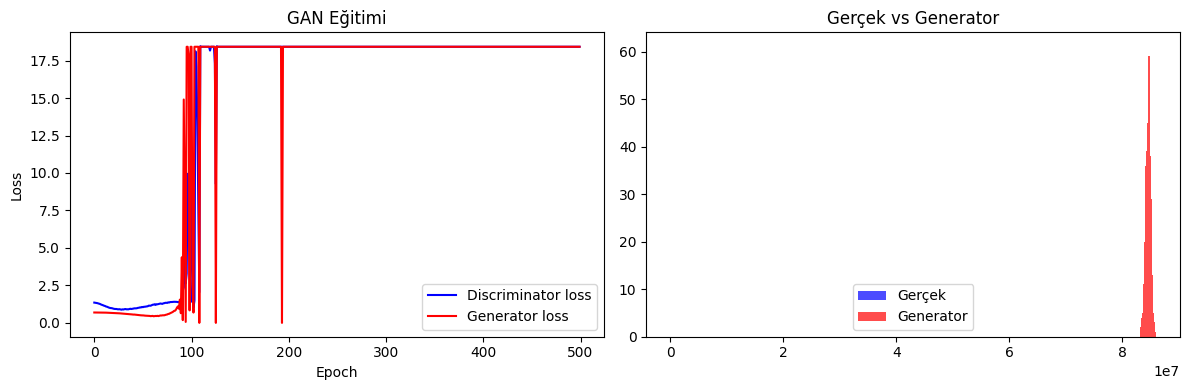

In [6]:
# ══════════════════════════════════════════════════════
# GAN EĞİTİMİ
# ══════════════════════════════════════════════════════
#
# Her epoch'ta 2 adım:
#
# ADIM 1: Discriminator'ı eğit
#   Gerçek veri → D → 1 olsun
#   Sahte veri  → D → 0 olsun
#
# ADIM 2: Generator'ı eğit
#   Sahte veri → D → 1 olsun (D'yi kandır!)
#   D'nin ağırlıkları sabit tutulur!
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Ağırlıkları sıfırla
G_W1 = np.random.randn(Z_DIM, H_DIM) * 0.1
G_b1 = np.zeros(H_DIM)
G_W2 = np.random.randn(H_DIM, X_DIM) * 0.1
G_b2 = np.zeros(X_DIM)
D_W1 = np.random.randn(X_DIM, H_DIM) * 0.1
D_b1 = np.zeros(H_DIM)
D_W2 = np.random.randn(H_DIM, 1) * 0.1
D_b2 = np.zeros(1)

lr = 0.01
N = 32  # batch boyutu

d_losses = []
g_losses = []

for epoch in range(500):

    # ── ADIM 1: DİSCRİMİNATOR EĞİTİMİ ───────────────
    # Gerçek veri
    x_gercek = np.random.normal(5, 1, (N, 1))
    d_gercek, h_gercek = discriminator(x_gercek)

    # Sahte veri
    z = np.random.randn(N, Z_DIM)
    x_sahte, h_gen = generator(z)
    d_sahte, h_disc_sahte = discriminator(x_sahte)

    # D loss: gerçek→1, sahte→0
    # Binary cross entropy
    d_loss = -np.mean(np.log(d_gercek + 1e-8) +
                      np.log(1 - d_sahte + 1e-8))
    d_losses.append(d_loss)

    # D gradient — gerçek için
    grad_d_gercek = -(1 - d_gercek) / N
    grad_h_gercek = grad_d_gercek * (h_gercek > 0)
    D_W2 -= lr * h_gercek.T @ grad_d_gercek
    D_b2 -= lr * np.sum(grad_d_gercek, axis=0)
    D_W1 -= lr * x_gercek.T @ grad_h_gercek
    D_b1 -= lr * np.sum(grad_h_gercek, axis=0)

    # D gradient — sahte için
    grad_d_sahte = d_sahte / N
    grad_h_sahte = grad_d_sahte * (h_disc_sahte > 0)
    D_W2 -= lr * h_disc_sahte.T @ grad_d_sahte
    D_b2 -= lr * np.sum(grad_d_sahte, axis=0)

    # ── ADIM 2: GENERATOR EĞİTİMİ ────────────────────
    z = np.random.randn(N, Z_DIM)
    x_sahte, h_gen = generator(z)
    d_out, h_disc = discriminator(x_sahte)

    # G loss: D'yi kandır → d_out → 1 olsun
    g_loss = -np.mean(np.log(d_out + 1e-8))
    g_losses.append(g_loss)

    # G gradient
    grad_g = -(1 - d_out) / N
    grad_h_disc = grad_g * (h_disc > 0)
    grad_x_sahte = grad_h_disc @ D_W1.T
    grad_h_gen = grad_x_sahte * (h_gen > 0)
    G_W2 -= lr * h_gen.T @ grad_x_sahte
    G_b2 -= lr * np.sum(grad_x_sahte, axis=0)
    G_W1 -= lr * z.T @ grad_h_gen
    G_b1 -= lr * np.sum(grad_h_gen, axis=0)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d}: D_loss={d_loss:.4f}, G_loss={g_loss:.4f}")

# Grafik
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(d_losses, 'b-', label='Discriminator loss')
plt.plot(g_losses, 'r-', label='Generator loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Eğitimi")
plt.legend()

# Generator'ın ürettiği veriyi göster
z = np.random.randn(1000, Z_DIM)
x_sahte, _ = generator(z)
x_gercek = np.random.normal(5, 1, 1000)

plt.subplot(1, 2, 2)
plt.hist(x_gercek, bins=50, alpha=0.7, color='blue', label='Gerçek')
plt.hist(x_sahte, bins=50, alpha=0.7, color='red', label='Generator')
plt.title("Gerçek vs Generator")
plt.legend()
plt.tight_layout()
plt.show()

Epoch    0: D=1.3863, G=0.6931
Epoch  200: D=1.3872, G=0.6931
Epoch  400: D=1.3874, G=0.6931
Epoch  600: D=1.3865, G=0.6931
Epoch  800: D=1.3842, G=0.6931


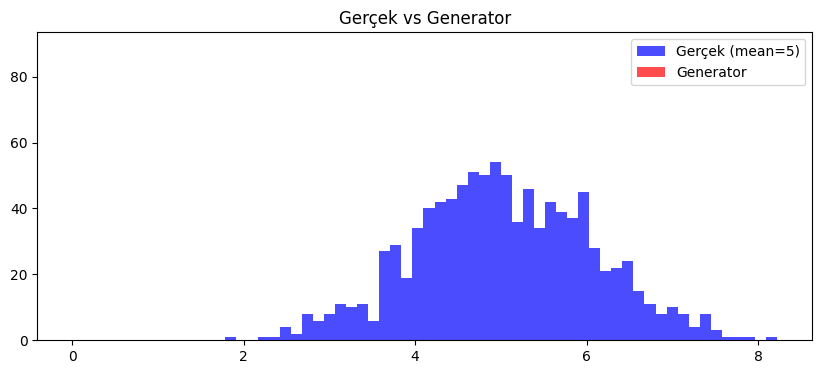


Generator ortalama: 0.01 (hedef: 5)
Generator std:      0.00 (hedef: 1)


In [8]:
# ══════════════════════════════════════════════════════
# GAN — DÜZELTİLMİŞ VERSİYON
# lr küçültüldü, gradient clipping eklendi
# ══════════════════════════════════════════════════════

np.random.seed(42)

G_W1 = np.random.randn(Z_DIM, H_DIM) * 0.01
G_b1 = np.zeros(H_DIM)
G_W2 = np.random.randn(H_DIM, X_DIM) * 0.01
G_b2 = np.zeros(X_DIM)
D_W1 = np.random.randn(X_DIM, H_DIM) * 0.01
D_b1 = np.zeros(H_DIM)
D_W2 = np.random.randn(H_DIM, 1) * 0.01
D_b2 = np.zeros(1)

lr = 0.0001  # çok küçük lr
N  = 64

d_losses = []
g_losses = []

for epoch in range(1000):

    # Gerçek veri
    x_gercek = np.random.normal(5, 1, (N, 1))
    d_gercek, h_d_gercek = discriminator(x_gercek)

    # Sahte veri
    z = np.random.randn(N, Z_DIM)
    x_sahte, h_gen = generator(z)
    d_sahte, h_d_sahte = discriminator(x_sahte)

    # D loss
    d_loss = -np.mean(np.log(d_gercek + 1e-8) +
                      np.log(1 - d_sahte + 1e-8))
    d_losses.append(d_loss)

    # D güncelle — gerçek
    grad_real = -(1/N) * (1 - d_gercek)
    grad_h_real = grad_real * (h_d_gercek > 0)
    D_W2 -= lr * np.clip(h_d_gercek.T @ grad_real, -1, 1)
    D_b2 -= lr * np.clip(np.sum(grad_real, axis=0), -1, 1)
    D_W1 -= lr * np.clip(x_gercek.T @ grad_h_real, -1, 1)
    D_b1 -= lr * np.clip(np.sum(grad_h_real, axis=0), -1, 1)

    # D güncelle — sahte
    grad_fake = (1/N) * d_sahte
    grad_h_fake = grad_fake * (h_d_sahte > 0)
    D_W2 -= lr * np.clip(h_d_sahte.T @ grad_fake, -1, 1)
    D_b2 -= lr * np.clip(np.sum(grad_fake, axis=0), -1, 1)
    D_W1 -= lr * np.clip(x_sahte.T @ grad_h_fake, -1, 1)
    D_b1 -= lr * np.clip(np.sum(grad_h_fake, axis=0), -1, 1)

    # G güncelle
    z = np.random.randn(N, Z_DIM)
    x_sahte, h_gen = generator(z)
    d_out, h_disc = discriminator(x_sahte)

    g_loss = -np.mean(np.log(d_out + 1e-8))
    g_losses.append(g_loss)

    grad_g = -(1/N) * (1 - d_out)
    grad_h_disc = grad_g * (h_disc > 0)
    grad_x = grad_h_disc @ D_W1.T
    grad_h_gen = grad_x * (h_gen > 0)
    G_W2 -= lr * np.clip(h_gen.T @ grad_x, -1, 1)
    G_b2 -= lr * np.clip(np.sum(grad_x, axis=0), -1, 1)
    G_W1 -= lr * np.clip(z.T @ grad_h_gen, -1, 1)
    G_b1 -= lr * np.clip(np.sum(grad_h_gen, axis=0), -1, 1)

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d}: D={d_loss:.4f}, G={g_loss:.4f}")

# Görselleştir
z = np.random.randn(1000, Z_DIM)
x_sahte, _ = generator(z)
x_gercek = np.random.normal(5, 1, 1000)

plt.figure(figsize=(10, 4))
plt.hist(x_gercek, bins=50, alpha=0.7, color='blue', label='Gerçek (mean=5)')
plt.hist(x_sahte, bins=50, alpha=0.7, color='red', label='Generator')
plt.title("Gerçek vs Generator")
plt.legend()
plt.show()

print(f"\nGenerator ortalama: {x_sahte.mean():.2f} (hedef: 5)")
print(f"Generator std:      {x_sahte.std():.2f} (hedef: 1)")

In [9]:
# ══════════════════════════════════════════════════════
# GANs ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║              GANs ÖZET                           ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  İki ağ birbirine karşı yarışır:                 ║")
print("║                                                  ║")
print("║  Generator (Sahtekar):                           ║")
print("║    Gürültü → gerçekçi görüntü üret               ║")
print("║    D'yi kandırmaya çalışır                       ║")
print("║                                                  ║")
print("║  Discriminator (Dedektif):                       ║")
print("║    Gerçek mi sahte mi ayırt et                   ║")
print("║    G'yi yakalamaya çalışır                       ║")
print("║                                                  ║")
print("║  Eğitim sonunda:                                 ║")
print("║    G o kadar iyi ki D %50 tahmin eder            ║")
print("║    = para atmaktan farksız!                      ║")
print("║                                                  ║")
print("║  Zorluklar:                                      ║")
print("║    Mode collapse → G hep aynı şey üretir         ║")
print("║    Eğitim dengesiz → lr çok önemli               ║")
print("║    Gerçekte PyTorch/TensorFlow ile yapılır       ║")
print("║                                                  ║")
print("║  Kullanım alanları:                              ║")
print("║    Sahte yüz üretme (thispersondoesnotexist.com) ║")
print("║    Style Transfer                                ║")
print("║    Veri artırma                                  ║")
print("║    Deepfake                                      ║")
print("╚══════════════════════════════════════════════════╝")

print("\n=== ASSIGNMENT 3 TAMAMLANDI ===")
print("✅ Q1: RNN Captioning")
print("✅ Q2: LSTM")
print("✅ Q3: Network Visualization + Fooling Images")
print("✅ Q4: Style Transfer")
print("✅ Q5: GANs")

╔══════════════════════════════════════════════════╗
║              GANs ÖZET                           ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  İki ağ birbirine karşı yarışır:                 ║
║                                                  ║
║  Generator (Sahtekar):                           ║
║    Gürültü → gerçekçi görüntü üret               ║
║    D'yi kandırmaya çalışır                       ║
║                                                  ║
║  Discriminator (Dedektif):                       ║
║    Gerçek mi sahte mi ayırt et                   ║
║    G'yi yakalamaya çalışır                       ║
║                                                  ║
║  Eğitim sonunda:                                 ║
║    G o kadar iyi ki D %50 tahmin eder            ║
║    = para atmaktan farksız!                      ║
║                                                  ║
║  Zorluklar:                                 